# Polish Public Tenders — getting started

Welcome. This notebook shows how to use the [Polish Public Tenders Dataset](https://github.com/atlasprzetargow/polish-tenders-dataset) end-to-end: load it, query it, plot it, and interpret the numbers.

**What you'll learn:**
1. Load the Parquet file directly from GitHub (no local download, no clone)
2. Basic descriptive stats: market size, activity by region, top industries
3. Join `tenders` with `contractors` / `buyers` aggregates
4. A concrete analysis: market concentration per province (Herfindahl index)

**Prerequisites:** `pandas`, `pyarrow`, `duckdb`, `matplotlib`. Install once:

```
pip install pandas pyarrow duckdb matplotlib
```

**Anonymization note.** Contractors classified as natural persons (CEIDG sole proprietors) appear as `contractor_name = "[Osoba fizyczna]"` with a salted hash in `contractor_national_id`. Aggregates preserve this identity so cross-year joins still work. See [schema/tenders.md → Anonymization](https://github.com/atlasprzetargow/polish-tenders-dataset/blob/main/schema/tenders.md#anonymization) for the full detection rules.


## 1. Load the data

In [1]:
import pandas as pd

URL = "https://github.com/atlasprzetargow/polish-tenders-dataset/raw/main/data/tenders_2025.parquet"

# Parquet is columnar — only read the columns you need to save bandwidth.
cols = [
    "id", "title", "buyer", "buyer_nip", "city", "province",
    "cpv_code", "notice_type", "order_type", "date",
    "estimated_value", "currency",
    "contractor_name", "contractor_national_id",
    "is_duplicate", "source",
]
df = pd.read_parquet(URL, columns=cols)
df.shape


(733453, 16)

2025 sample — **733 453 tender notices** (BZP + TED combined, before deduplication).

In [2]:
# For deduplicated analyses, filter out TED notices that duplicate a BZP entry.
df = df[df["is_duplicate"] == False]
print(f"After dedup: {len(df):,} rows")
df.head(3)


After dedup: 733,453 rows


,id,title,buyer,buyer_nip,city,province,cpv_code,notice_type,order_type,date,estimated_value,currency,contractor_name,contractor_national_id,is_duplicate,source
0,2025/BZP 00000001,Odbieranie i transport odpadów komunalnych pow...,Gmina Międzybórz,9111777759,Międzybórz,PL02,90500000-2 (Usługi związane z odpadami),TenderResultNotice,NaN,2025-01-01,643946.72,PLN,Zakład Gospodarki Komunalnej i Mieszkaniowej S...,9112008135,False,bzp
1,2025/BZP 00000002,Opracowanie projektu planu ogólnego gminy Male...,Gmina Malechowo,4990530407,Malechowo,PL32,71410000-5 (Usługi planowania przestrzennego),TenderResultNotice,NaN,2025-01-01,364000.00,PLN,[Osoba fizyczna],anon-08a04bcd0f,False,bzp
2,2025/BZP 00000003,Zakup aparatu ultrasonograficznego,Samodzielny Publiczny Zakład Opieki Zdrowotnej...,5651337631,Włodawa,PL06,33112200-0 (Aparaty ultrasonograficzne),ContractPerformingNotice,NaN,2025-01-01,278100.00,PLN,TMS Sp. z o.o.,5211004948,False,bzp


## 2. Market by province

Province codes are [NUTS-2](https://ec.europa.eu/eurostat/web/nuts/background) — `PL11` Łódzkie, `PL12` Mazowieckie (Warsaw area), `PL21` Małopolskie (Kraków), `PL22` Śląskie, `PL51` Dolnośląskie (Wrocław), etc.

In [3]:
PROVINCES = {
    "PL11": "Łódzkie",    "PL12": "Mazowieckie",
    "PL21": "Małopolskie", "PL22": "Śląskie",
    "PL31": "Lubelskie",   "PL32": "Podkarpackie",
    "PL33": "Świętokrzyskie", "PL34": "Podlaskie",
    "PL41": "Wielkopolskie", "PL42": "Zachodniopomorskie",
    "PL43": "Lubuskie",    "PL51": "Dolnośląskie",
    "PL52": "Opolskie",    "PL61": "Kujawsko-Pomorskie",
    "PL62": "Warmińsko-Mazurskie", "PL63": "Pomorskie",
}

by_prov = (
    df.groupby("province")
      .agg(n=("id", "count"), total_value_pln=("estimated_value", "sum"))
      .sort_values("n", ascending=False)
)
by_prov.index = by_prov.index.map(lambda x: f"{x} · {PROVINCES.get(x, x)}")
by_prov["total_value_pln"] = by_prov["total_value_pln"].round(0)
by_prov.head(10)


,n,total_value_pln
province,,
PL14 · PL14,107849,6.599229e+10
PL24 · PL24,63041,3.057246e+10
PL12 · Mazowieckie,57591,4.136805e+10
PL30 · PL30,48308,3.404916e+10
PL02 · PL02,45606,2.800878e+10
PL18 · PL18,36730,1.352982e+10
PL06 · PL06,35725,2.833033e+10
PL22 · Śląskie,35424,1.803430e+10
PL10 · PL10,34214,2.335872e+10


## 3. Top industries — CPV divisions

CPV codes follow the 8-digit EU format. First two digits are the division — `45` construction works, `33` medical equipment, `48`/`72` IT, `15` food, `34` transport equipment. Extract the division for quick industry summaries.

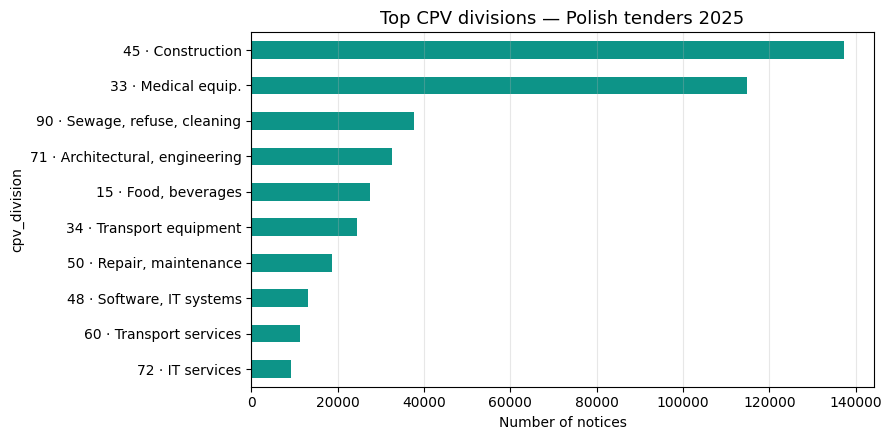

In [4]:
import matplotlib.pyplot as plt

CPV_DIVISIONS = {
    "45": "Construction",
    "33": "Medical equip.",
    "15": "Food, beverages",
    "72": "IT services",
    "48": "Software, IT systems",
    "60": "Transport services",
    "71": "Architectural, engineering",
    "50": "Repair, maintenance",
    "34": "Transport equipment",
    "90": "Sewage, refuse, cleaning",
}

# Primary CPV = first code in comma-separated list; first 2 digits = division.
df["cpv_division"] = df["cpv_code"].fillna("").str.split(",").str[0].str.slice(0, 2)
top = (
    df[df["cpv_division"].isin(CPV_DIVISIONS.keys())]
      .groupby("cpv_division")
      .size()
      .sort_values(ascending=False)
)
top.index = top.index.map(lambda d: f"{d} · {CPV_DIVISIONS[d]}")

fig, ax = plt.subplots(figsize=(9, 4.5))
top.plot.barh(ax=ax, color="#0d9488")
ax.set_title("Top CPV divisions — Polish tenders 2025", fontsize=13)
ax.set_xlabel("Number of notices")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Market concentration per province — Herfindahl-Hirschman Index

The HHI measures how concentrated a market is. Sum of squared market shares of each supplier (here: contractor) in each province. **Below 1 500 = competitive**, **1 500–2 500 = moderate concentration**, **above 2 500 = concentrated**. Anonymized contractors count as distinct identities (via their stable salted hash), so the metric is unaffected by anonymization.

In [5]:
# Use result notices (awards) where we actually know the winner.
awards = df[df["contractor_national_id"].notna() & df["estimated_value"].notna()].copy()

def hhi(group):
    shares = group["estimated_value"] / group["estimated_value"].sum()
    return (shares ** 2).sum() * 10_000  # HHI is conventionally on 0..10_000

hhi_by_province = (
    awards.groupby(["province", "contractor_national_id"])["estimated_value"].sum()
          .reset_index()
          .groupby("province")
          .apply(hhi)
          .sort_values(ascending=False)
          .round(0)
)
hhi_by_province.index = hhi_by_province.index.map(lambda x: f"{x} · {PROVINCES.get(x, x)}")
hhi_by_province.head(16)


province
PL06 · PL06            3709.0
PL16 · PL16            1930.0
PL30 · PL30            1023.0
PL32 · Podkarpackie     987.0
PL10 · PL10             669.0
PL12 · Mazowieckie      378.0
PL04 · PL04             134.0
PL20 · PL20             102.0
PL08 · PL08              62.0
PL26 · PL26              61.0
PL02 · PL02              55.0
PL22 · Śląskie           45.0
PL14 · PL14              32.0
PL24 · PL24              29.0
PL18 · PL18              26.0
PL28 · PL28              23.0
dtype: float64

High HHI typically flags either a genuinely tiny regional market (few tenders, so a single contractor dominates) or a deeply concentrated industry. Cross-check with the `n` column from §2: a province with <1 000 notices is a small base, so HHI fluctuates a lot.

## 5. Joining with the `contractors` aggregate

The repo also ships [`contractors.parquet`](https://github.com/atlasprzetargow/polish-tenders-dataset/blob/main/data/contractors.parquet) — one row per contractor NIP with pre-computed totals, trends, and top partners. Join it in when you need contractor-level context faster than aggregating tenders yourself.

In [6]:
contractors = pd.read_parquet(
    "https://github.com/atlasprzetargow/polish-tenders-dataset/raw/main/data/contractors.parquet",
    columns=["nip", "name", "total_wins", "total_value"],
)
top_contractors = contractors.sort_values("total_wins", ascending=False).head(15)
top_contractors


,nip,name,total_wins,total_value
12795,5250007313,Poczta Polska S.A.,6238,1.378791e+10
11943,8942556799,Urtica Sp. z o.o.,3405,4.120565e+09
9763,5272706082,PGNiG Obrót Detaliczny Sp. z o.o.,3241,1.251718e+10
16417,5210421928,STRABAG Sp. z o.o.,2611,1.708863e+10
25018,8490000039,Bialmed Sp. z o.o.,2517,7.171197e+08
20082,6481997718,ZARYS International Group Sp. z o. o. Sp. k.,2463,3.810111e+08
81651,7880008829,Aesculap Chifa Sp. z o.o.,2241,8.580180e+08
81160,6340125442,Salus International Sp. z o.o.,2238,1.225156e+09
17151,7740001454,Polski Koncern Naftowy ORLEN Spółka Akcyjna,1808,1.098387e+12
7474,9521000289,Medtronic Poland Sp. z o.o.,1623,4.071684e+09


Notice that rows where `name = "[Osoba fizyczna]"` bubble up when a single sole proprietor wins across many small tenders. Their `nip` starts with `anon-` — the stable salted hash that lets you follow the same (anonymized) entity across years while never exposing personal data.

## 6. DuckDB alternative — SQL straight over HTTP

If you prefer SQL (or want to skip the pandas memory overhead on the full dataset), DuckDB reads Parquet directly from HTTP URLs. No local download, no database setup.

In [7]:
import duckdb

con = duckdb.connect()
con.execute("""
  SELECT province, COUNT(*) AS n, SUM(estimated_value)::BIGINT AS total_pln
  FROM 'https://github.com/atlasprzetargow/polish-tenders-dataset/raw/main/data/tenders_2025.parquet'
  WHERE is_duplicate = false
    AND notice_type LIKE 'Contract%'
  GROUP BY province
  ORDER BY total_pln DESC NULLS LAST
  LIMIT 5;
""").fetchdf()


,province,n,total_pln
0,PL14,66759,44905378987
1,PL24,39428,20242946930
2,PL12,35712,19540652008
3,PL02,26624,18256375148
4,PL32,15983,14346345838


## Where to go next

- **Full schema:** [`schema/tenders.md`](https://github.com/atlasprzetargow/polish-tenders-dataset/tree/main/schema) — all 43 columns documented
- **Anonymization details:** [`pii_utils.py`](https://github.com/atlasprzetargow/polish-tenders-dataset/blob/main/pii_utils.py) — the detection logic, all MIT-licensed
- **Citation:** [`CITATION.cff`](https://github.com/atlasprzetargow/polish-tenders-dataset/blob/main/CITATION.cff) — machine-readable, Zotero/Mendeley-compatible
- **Real-time access:** [REST API](https://atlasprzetargow.pl/api) or the [MCP Server for AI assistants](https://github.com/atlasprzetargow/mcp-server)
- **Report issues:** [GitHub Issues](https://github.com/atlasprzetargow/polish-tenders-dataset/issues)

If you build something interesting on top of this dataset (paper, notebook, visualization, dashboard) — email us at `contact@atlasprzetargow.pl`. Happy to amplify good work.